In [1]:
# ============================================================
# CELL 0: IMPORTS & GLOBAL SETTINGS
# ============================================================
#
# PURPOSE:
#   Load all third-party libraries once at the top so every
#   subsequent cell can rely on them without re-importing.
#   Keeping imports centralised also makes dependency audits
#   and version pinning much easier.
#
# KEY LIBRARY NOTES:
#   - hazm  : Persian NLP toolkit (normalisation, tokenisation,
#             stopword lists). Required for Farsi/Digikala text.
#   - tqdm  : Progress bars – wraps iterators and pandas .apply()
#             calls to give real-time feedback on long operations.
#   - scipy : Used to build sparse matrices (csr_matrix / hstack)
#             when combining TF-IDF features with numeric features.
#
# SETTINGS RATIONALE:
#   - warnings.filterwarnings('ignore') keeps the notebook output
#     clean during development; remove this in production so real
#     deprecation warnings are not silently swallowed.
#   - pd.set_option('display.max_colwidth', 100) prevents truncation
#     of long Persian comment text when inspecting DataFrames.
#   - tqdm.pandas() patches pd.Series/DataFrame so you can call
#     .progress_apply() instead of .apply() for progress bars.
# ============================================================

# Core libraries
import pandas as pd
import numpy as np
import warnings
import re
import pickle
import joblib
from pathlib import Path
from tqdm import tqdm

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Persian NLP
from hazm import Normalizer, word_tokenize, stopwords_list

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from scipy.sparse import csr_matrix, hstack

# ── Global settings ──────────────────────────────────────────
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 100)
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

# Activate tqdm integration with pandas .progress_apply()
tqdm.pandas()

print("✓ All libraries loaded successfully")


✓ All libraries loaded successfully


In [3]:
# ============================================================
# CELL 1: DATA LOADING & MERGING
# ============================================================
#
# PURPOSE:
#   Load the raw comments CSV (up to 6 M rows) and the products
#   CSV (up to 1.2 M rows), then LEFT JOIN them on product_id so
#   every comment is enriched with product-level metadata such as
#   category, average rating, and price.
#
# WHY nrows=200_000?
#   We cap at 200k rows for rapid iteration during development.
#   Once the pipeline is validated end-to-end, remove the nrows
#   limit (or increase it) to run on the full dataset.
#   For the full 6 M rows, consider chunked loading with
#   pd.read_csv(..., chunksize=500_000) and concatenating.
#
# MERGE STRATEGY – LEFT JOIN:
#   Using how='left' ensures we keep ALL comments even if a
#   product_id has no matching product row (e.g. deleted products).
#   Rows with no product match will have NaN in product columns;
#   we handle these in the Feature Engineering cell.
#
# OUTPUT:
#   merged_200k.csv  ─  enriched comment records ready for
#                       feature engineering.
# ============================================================

print("=" * 60)
print("Data Loading and Merging")
print("=" * 60)

# ── File paths ───────────────────────────────────────────────
# Adjust these paths to match your project directory layout.
comments_path = '../data/raw/digikala-comments.csv'
products_path = '../data/raw/digikala-products.csv'

# ── Load comments ────────────────────────────────────────────
print("\nLoading comments...")
comments_df = pd.read_csv(comments_path, nrows=200_000, encoding='utf-8-sig')
print(f"Comments shape: {comments_df.shape}")

# ── Load products ────────────────────────────────────────────
print("\nLoading products...")
products_df = pd.read_csv(products_path, nrows=200_000, encoding='utf-8-sig')
print(f"Products shape: {products_df.shape}")

# ── Sanity-check product_id matching ─────────────────────────
# A large number of unmatched comments may indicate a key mismatch
# (e.g. type mismatch: int vs string). Inspect carefully.
print("\nChecking product_id matching...")
unique_comment_products = comments_df['product_id'].nunique()
unique_products         = products_df['id'].nunique()
matching_products       = comments_df['product_id'].isin(products_df['id']).sum()

print(f"Unique product_id in comments : {unique_comment_products:,}")
print(f"Unique id in products         : {unique_products:,}")
print(f"Comments with matching product: {matching_products:,}")

# ── Merge ────────────────────────────────────────────────────
print("\nMerging datasets...")
merged_df = comments_df.merge(
    products_df,
    left_on='product_id',
    right_on='id',
    how='left',          # Keep all comments; fill missing product cols with NaN
    suffixes=('_comment', '_product')
)

print(f"\nMerged dataset shape        : {merged_df.shape}")
print(f"Rows WITH product info      : {merged_df['id_product'].notna().sum():,}")
print(f"Rows WITHOUT product info   : {merged_df['id_product'].isna().sum():,}")

print("\nSample of merged data:")
print(merged_df.head(3))

# ── Persist ──────────────────────────────────────────────────
output_path = '../data/processed/sentiment_analysis/merged_200k.csv'
merged_df.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"\n✓ Merged data saved → {output_path}")


Data Loading and Merging

Loading comments...
Comments shape: (200000, 15)

Loading products...
Products shape: (200000, 12)

Checking product_id matching...
Unique product_id in comments : 16,344
Unique id in products         : 139,779
Comments with matching product: 15,968

Merging datasets...

Merged dataset shape        : (200949, 27)
Rows WITH product info      : 16,917
Rows WITHOUT product info   : 184,032

Sample of merged data:
   id_comment           title  \
0    53672599  پیشنهاد نمیشود   
1     9897229    بسته بندی بد   
2    38074516        برس ریمل   

                                                                                          body  \
0                                                                              به درد نمیخوره    
1                                         می‌تونست به عنوان یه کالای فرهنگی بهتر بسته بندی بشه   
2  بسته بندیش خوب بود\r\n کاربرد و کیفیتشم خیلی خوبه من برای روغن زدم به مژه و لیفت ابرو خریدم   

       created_at  rate recommenda

In [4]:
# ============================================================
# CELL 2: FEATURE ENGINEERING
# ============================================================
#
# PURPOSE:
#   Transform raw merged data into a rich feature set that will
#   be used alongside TF-IDF text features during model training.
#   Having numeric/categorical features can meaningfully boost
#   accuracy because they capture signals the text alone misses
#   (e.g. a 5-star rating is a very strong positive signal).
#
# FEATURE GROUPS CREATED (7 groups):
#   1. Text features      – character & word counts of title/body
#   2. Recommendation     – binary encoded پیشنهاد میکنم / نمیکنم
#   3. Buyer status       – whether the reviewer bought the item
#   4. Rate               – normalised star rating + rate gap vs
#                           product average
#   5. Reactions          – like/dislike counts & like-ratio
#   6. Price              – discount % and availability flag
#   7. Temporal           – day / month / season from Persian date
#
# SENTIMENT LABEL LOGIC (create_sentiment_label):
#   Priority  → rate (numerical, more reliable)
#   Fallback  → recommendation_status (text signal)
#   Default   → 'neutral' when both are missing
#   Threshold → rate ≥ 4 = positive | rate ≤ 2 = negative
#
# NOTE ON NEUTRAL:
#   The neutral class is deliberately broad (rate == 3 OR both
#   signals missing). This often leads to class imbalance –
#   addressed later in the Model Improvement cell with SMOTE.
#
# OUTPUT:
#   data_with_features.csv  ─  all engineered features attached
# ============================================================

print("\n" + "=" * 60)
print("Feature Engineering")
print("=" * 60)

# Load merged data
df = pd.read_csv('../data/processed/sentiment_analysis/merged_200k.csv', encoding='utf-8-sig')
print(f"\nInitial shape: {df.shape}")

# ── 1 / 7  Text Features ─────────────────────────────────────
# Combine title + body into a single text field. Filling NaN with
# '' prevents string concatenation errors on missing values.
print("\n[1/7] Creating text-based features...")

df['full_text'] = df['title'].fillna('').astype(str) + ' ' + df['body'].fillna('').astype(str)

df['title_len']          = df['title'].fillna('').astype(str).apply(len)
df['body_len']           = df['body'].fillna('').astype(str).apply(len)
df['full_text_len']      = df['full_text'].apply(len)
df['total_text_len']     = df['title_len'] + df['body_len']

df['title_word_count']     = df['title'].fillna('').astype(str).apply(lambda x: len(x.split()))
df['body_word_count']      = df['body'].fillna('').astype(str).apply(lambda x: len(x.split()))
df['full_text_word_count'] = df['full_text'].apply(lambda x: len(x.split()))
df['total_word_count']     = df['title_word_count'] + df['body_word_count']

# Average word length – proxy for vocabulary complexity
df['avg_word_len'] = df.apply(
    lambda row: row['total_text_len'] / row['total_word_count']
    if row['total_word_count'] > 0 else 0,
    axis=1
)
print("  ✓ Text features created")

# ── 2 / 7  Recommendation Features ───────────────────────────
# Map Persian strings to binary; track missingness separately
# because missing ≠ neutral – it may indicate the form was skipped.
print("\n[2/7] Creating recommendation features...")
df['recommend_binary']  = df['recommendation_status'].map({'پیشنهاد میکنم': 1, 'پیشنهاد نمیکنم': 0})
df['recommend_missing'] = df['recommendation_status'].isna().astype(int)
print("  ✓ Recommendation features created")

# ── 3 / 7  Buyer Status Features ─────────────────────────────
# Reviews from verified buyers tend to be more credible / polarised.
print("\n[3/7] Creating buyer status features...")
df['is_buyer_binary']  = df['is_buyer'].map({'خریدار این کالا': 1, 'خریدار این کالا نیست': 0})
df['is_buyer_missing'] = df['is_buyer'].isna().astype(int)
print("  ✓ Buyer status features created")

# ── 4 / 7  Rate Features ─────────────────────────────────────
# rate_diff captures the reviewer's opinion RELATIVE to consensus –
# a 3-star on a 4.8-average product is essentially negative.
print("\n[4/7] Creating rate features...")
df['rate_missing']    = df['rate'].isna().astype(int)
df['rate_filled']     = df['rate'].fillna(df['rate'].median())
df['rate_diff']       = df['rate'] - df['Rate']          # 'Rate' = product avg rating column
df['rate_normalized'] = df['rate'] / 5.0
print("  ✓ Rate features created")

# ── 5 / 7  Reaction Features ─────────────────────────────────
# like_ratio = likes / (likes + dislikes). Default to 0.5 when
# there are no reactions (neutral prior instead of 0 or 1).
print("\n[5/7] Creating reaction features...")
df['likes']    = df['likes'].fillna(0).astype(int)
df['dislikes'] = df['dislikes'].fillna(0).astype(int)

df['total_reactions'] = df['likes'] + df['dislikes']
df['like_ratio'] = df.apply(
    lambda row: row['likes'] / row['total_reactions']
    if row['total_reactions'] > 0 else 0.5,
    axis=1
)
df['has_reactions'] = (df['total_reactions'] > 0).astype(int)
print("  ✓ Reaction features created")

# ── 6 / 7  Price Features ────────────────────────────────────
# Discount % may correlate with sentiment: people are happier when
# they feel they got a deal; heavy discounts can also signal low
# quality, adding nuance.
print("\n[6/7] Creating price features...")
df['price_discount'] = (
    (df['min_price_last_month'] - df['Price']) / df['min_price_last_month'] * 100
).fillna(0)
df['price_available'] = df['Price'].notna().astype(int)
print("  ✓ Price features created")

# ── 7 / 7  Temporal Features ─────────────────────────────────
# Persian (Jalali) calendar dates need custom parsing. Weekend
# detection and seasonality may reveal time-based sentiment shifts
# (e.g. gift season → more positive reviews).
print("\n[7/7] Creating temporal features...")

persian_months = {
    'فروردین': 1, 'اردیبهشت': 2, 'خرداد': 3,
    'تیر': 4,    'مرداد': 5,    'شهریور': 6,
    'مهر': 7,    'آبان': 8,     'آذر': 9,
    'دی': 10,    'بهمن': 11,    'اسفند': 12
}

def parse_persian_date(date_str):
    """
    Parse a Persian date string formatted as 'DD MonthName YYYY'.
    Returns (day, month_number, year) or (None, None, None) on failure.
    """
    if pd.isna(date_str):
        return None, None, None
    try:
        parts = str(date_str).split()
        day   = int(parts[0])
        month = persian_months.get(parts[1], 0)
        year  = int(parts[2])
        return day, month, year
    except Exception:
        return None, None, None

df[['day', 'month', 'year']] = df['created_at'].apply(
    lambda x: pd.Series(parse_persian_date(x))
)

# Persian weekend = Thursday (day index 5) and Friday (day index 6)
df['is_weekend'] = df['day'].apply(lambda x: 1 if pd.notna(x) and x % 7 in [5, 6] else 0)
df['season']     = df['month'].apply(lambda x: (x % 12 + 3) // 3 if pd.notna(x) else 0)
print("  ✓ Temporal features created")

# ── Sentiment Labels ──────────────────────────────────────────
print("\nCreating sentiment labels...")

def create_sentiment_label(row):
    """
    Assign a 3-class sentiment label using a priority hierarchy:
      1. Star rating  (rate column)  – most reliable signal
      2. Recommendation status       – fallback when rate is missing
      3. Both missing                – assigned 'neutral' as safe default

    Thresholds:
      rate >= 4  → positive   (4-star and 5-star)
      rate <= 2  → negative   (1-star and 2-star)
      rate == 3  → neutral    (ambiguous middle ground)
    """
    rate      = row['rate']
    recommend = row['recommendation_status']

    if pd.isna(rate) and pd.isna(recommend):
        return 'neutral'            # No signal available

    if not pd.isna(rate):
        if rate >= 4:   return 'positive'
        elif rate <= 2: return 'negative'
        else:           return 'neutral'

    # Rate is missing – use recommendation text as fallback
    if recommend == 'پیشنهاد میکنم':    return 'positive'
    elif recommend == 'پیشنهاد نمیکنم': return 'negative'
    else:                                return 'neutral'

df['sentiment'] = df.apply(create_sentiment_label, axis=1)

print("\nSentiment distribution:")
sentiment_counts = df['sentiment'].value_counts()
sentiment_pct    = df['sentiment'].value_counts(normalize=True) * 100
for label in ['positive', 'neutral', 'negative']:
    count = sentiment_counts.get(label, 0)
    pct   = sentiment_pct.get(label, 0)
    print(f"  {label:8s}: {count:6,} ({pct:5.2f}%)")

# ── Save ──────────────────────────────────────────────────────
output_path = '../data/processed/sentiment_analysis/data_with_features.csv'
df.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"\n✓ Data with features saved → {output_path}")
print(f"Final shape: {df.shape}")

# ── Feature Summary ───────────────────────────────────────────
feature_cols = [
    'full_text', 'full_text_len', 'title_len', 'body_len', 'total_text_len',
    'title_word_count', 'body_word_count', 'full_text_word_count', 'total_word_count', 'avg_word_len',
    'recommend_binary', 'recommend_missing',
    'is_buyer_binary', 'is_buyer_missing',
    'rate_missing', 'rate_filled', 'rate_diff', 'rate_normalized',
    'likes', 'dislikes', 'total_reactions', 'like_ratio', 'has_reactions',
    'price_discount', 'price_available',
    'day', 'year', 'month', 'is_weekend', 'season'
]
print(f"\nTotal engineered features: {len(feature_cols)}")
print("\nFeature statistics:")
print(df[feature_cols].describe().T)



Feature Engineering

Initial shape: (200949, 27)

[1/7] Creating text-based features...
  ✓ Text features created

[2/7] Creating recommendation features...
  ✓ Recommendation features created

[3/7] Creating buyer status features...
  ✓ Buyer status features created

[4/7] Creating rate features...
  ✓ Rate features created

[5/7] Creating reaction features...
  ✓ Reaction features created

[6/7] Creating price features...
  ✓ Price features created

[7/7] Creating temporal features...
  ✓ Temporal features created

Creating sentiment labels...

Sentiment distribution:
  positive: 131,159 (65.27%)
  neutral : 34,605 (17.22%)
  negative: 35,185 (17.51%)

✓ Data with features saved → ../data/processed/sentiment_analysis/data_with_features.csv
Final shape: (200949, 56)

Total engineered features: 30

Feature statistics:
                         count         mean        std     min          25%  \
full_text_len         200949.0    55.515225  67.844302     3.0    20.000000   
title_len  

In [5]:
# ============================================================
# CELL 3: PERSIAN TEXT PREPROCESSING FUNCTION
# ============================================================
#
# PURPOSE:
#   Define a reusable text-cleaning pipeline for Persian (Farsi)
#   text. Good preprocessing is CRITICAL for Persian NLP because:
#     • Arabic/Persian writing uses different Unicode codepoints
#       for visually identical characters (e.g. ی vs ي, ک vs ك).
#       The Hazm Normalizer resolves these into a standard form.
#     • Half-space (zero-width non-joiner, U+200C) is heavily used
#       in Persian compound words – Hazm handles this too.
#     • Persian stopwords are frequent and carry little sentiment
#       signal; removing them reduces noise in TF-IDF.
#
# STOPWORD NOTE:
#   The stopword filtering lines are currently commented out.
#   This was intentional: some stopwords such as 'نه' (no) and
#   'نمی' (doesn't) are CRITICAL for sentiment.  If you want to
#   re-enable stopword removal, un-comment the sentiment_words
#   block to preserve those words before filtering.
#
# PIPELINE STEPS:
#   1. Hazm Normalizer  – canonical Unicode form, ZWNJ, punctuation
#   2. Strip Latin/digits – product reviews in Persian rarely rely
#      on English numerals for sentiment; removing them reduces noise.
#   3. Remove non-word characters – strip leftover punctuation.
#   4. Tokenize – Hazm tokeniser handles Persian morphology better
#      than naïve split().
#   5. (Optional) Stopword removal – see note above.
#   6. Drop single-character tokens – mostly noise.
# ============================================================

from hazm import Normalizer, word_tokenize, stopwords_list
import re

# ── Initialise Hazm normaliser ────────────────────────────────
# Create once here; reused by every call to preprocess_persian_text.
# Instantiating inside the function would be ~50x slower on 6 M rows.
normalizer = Normalizer()

# ── (Optional) Sentiment-aware stopword list ──────────────────
# Un-comment this block to enable stopword filtering while
# preserving the most important sentiment-carrying words.
#
persian_stopwords = set(stopwords_list())
sentiment_words = {
    'خوب', 'بد', 'عالی', 'مناسب', 'ضعیف', 'بهترین', 'بدترین',
    'خیلی', 'زیاد', 'کم', 'نه', 'نمی', 'نیست'
}
stop_words = persian_stopwords - sentiment_words   # Keep sentiment words

def preprocess_persian_text(text):
    """
    Clean and normalise a Persian product review comment.

    Args:
        text (str | float): Raw comment text. NaN/None-safe.

    Returns:
        str: Whitespace-separated cleaned tokens, or '' if input is empty.

    Pipeline:
        normalize → strip latin+digits → strip punctuation →
        collapse whitespace → tokenise → (optional stopwords) →
        drop single-char tokens → rejoin
    """
    if pd.isna(text) or text == '':
        return ''

    # Step 1: Hazm normalisation (canonical Unicode, ZWNJ, etc.)
    text = normalizer.normalize(str(text))

    # Step 2: Remove English letters and Arabic/Persian numerals
    #   Adjust the regex if you want to keep Persian digits (۰-۹).
    text = re.sub(r'[a-zA-Z0-9]+', ' ', text)

    # Step 3: Remove punctuation and special characters
    text = re.sub(r'[^\w\s]', ' ', text)

    # Step 4: Collapse multiple whitespace characters into a single space
    text = re.sub(r'\s+', ' ', text).strip()

    # Step 5: Hazm word tokenisation
    tokens = word_tokenize(text)

    # Step 6: (Optional) Remove stopwords – see block above to enable
    # tokens = [w for w in tokens if w not in stop_words and len(w) > 1]

    # Step 7: Drop very short tokens (single characters, likely noise)
    tokens = [w for w in tokens if len(w) > 1]

    return ' '.join(tokens)

print("✅ Text preprocessing function defined")
print("   Tip: Run a quick sanity check on a sample comment before applying to the full dataset.")


✅ Text preprocessing function defined
   Tip: Run a quick sanity check on a sample comment before applying to the full dataset.


In [6]:
# ============================================================
# CELL 4: APPLY TEXT PREPROCESSING  (was: Section 3)
# ============================================================
#
# PURPOSE:
#   Apply the preprocess_persian_text() function defined in Cell 3
#   to every comment, creating three new 'cleaned' columns.
#
# WHY THREE SEPARATE COLUMNS?
#   - full_text_cleaned : primary input for TF-IDF (title + body)
#   - title_cleaned     : useful if you want title-only TF-IDF features
#                         or want to weight titles more heavily
#   - body_cleaned      : useful for body-only analysis; the body is
#                         typically longer and more expressive
#
# PERFORMANCE TIP (for 6 M rows):
#   On the full dataset this cell will take several minutes.
#   Consider using multiprocessing:
#
#       from multiprocessing import Pool, cpu_count
#       with Pool(cpu_count()) as p:
#           df['full_text_cleaned'] = p.map(preprocess_persian_text, df['full_text'])
#
#   Or use Dask for out-of-core processing if RAM is a constraint.
#
# OUTPUT COLUMNS ADDED:
#   full_text_cleaned  – cleaned title + body
#   title_cleaned      – cleaned title only
#   body_cleaned       – cleaned body only
#   cleaned_length     – character count of full_text_cleaned
#   cleaned_word_count – token count of full_text_cleaned
# ============================================================

print("\n" + "=" * 80)
print("CELL 4: TEXT PREPROCESSING")
print("=" * 80)

# Apply preprocessing to the combined title+body field
print("\nApplying preprocessing to full_text...")
df['full_text_cleaned'] = df['full_text'].apply(preprocess_persian_text)

# Apply preprocessing to individual fields separately
# (useful for feature ablation studies)
print("Applying preprocessing to title...")
df['title_cleaned'] = df['title'].apply(preprocess_persian_text)

print("Applying preprocessing to body...")
df['body_cleaned'] = df['body'].apply(preprocess_persian_text)

# Derived length features on the cleaned text
# These often differ significantly from raw lengths (emoji, punctuation removed)
df['cleaned_length']     = df['full_text_cleaned'].str.len()
df['cleaned_word_count'] = df['full_text_cleaned'].str.split().str.len()

# ── Sanity check – show before / after comparison ────────────
print("\n" + "=" * 80)
print("Sample: Original vs Cleaned text")
print("=" * 80)
for idx in range(min(3, len(df))):
    print(f"\n--- Row {idx + 1} ---")
    print(f"Original : {df['full_text'].iloc[idx][:120]}...")
    print(f"Cleaned  : {df['full_text_cleaned'].iloc[idx][:120]}...")

# ── Persist ──────────────────────────────────────────────────
output_file = '../data/processed/sentiment_analysis/preprocessed_data.csv'
print("\n" + "=" * 80)
print(f"Saving preprocessed data → {output_file}...")
df.to_csv(output_file, index=False)
print(f"✅ Saved {len(df):,} records successfully!")
print("=" * 80)



CELL 4: TEXT PREPROCESSING

Applying preprocessing to full_text...
Applying preprocessing to title...
Applying preprocessing to body...

Sample: Original vs Cleaned text

--- Row 1 ---
Original : پیشنهاد نمیشود به درد نمیخوره ...
Cleaned  : پیشنهاد نمی شود به درد نمیخوره...

--- Row 2 ---
Original : بسته بندی بد می‌تونست به عنوان یه کالای فرهنگی بهتر بسته بندی بشه...
Cleaned  : بسته بندی بد می تونست به عنوان یه کالای فرهنگی بهتر بسته بندی بشه...

--- Row 3 ---
Original : برس ریمل بسته بندیش خوب بود
 کاربرد و کیفیتشم خیلی خوبه من برای روغن زدم به مژه و لیفت ابرو خریدم...
Cleaned  : برس ریمل بسته بندیش خوب بود کاربرد کیفیتشم خیلی خوبه من برای روغن زدم به مژه لیفت ابرو خریدم...

Saving preprocessed data → ../data/processed/sentiment_analysis/preprocessed_data.csv...
✅ Saved 200,949 records successfully!



CELL 5: TEXT EDA

📂 Loading preprocessed data...
✅ Loaded 200,949 records

--------------------------------------------------------------------------------
5.1: TEXT LENGTH ANALYSIS BY SENTIMENT
--------------------------------------------------------------------------------

📊 Text length statistics by sentiment:
          cleaned_text_length                                               \
                        count       mean        std  min   25%   50%   75%   
sentiment                                                                    
negative              35168.0  66.418477  72.287828  2.0  26.0  46.0  81.0   
neutral               34582.0  56.268897  67.441558  2.0  19.0  36.0  69.0   
positive             131081.0  48.462256  61.950076  2.0  17.0  31.0  58.0   

                  cleaned_word_count                                       \
              max              count       mean        std  min  25%  50%   
sentiment                                                   

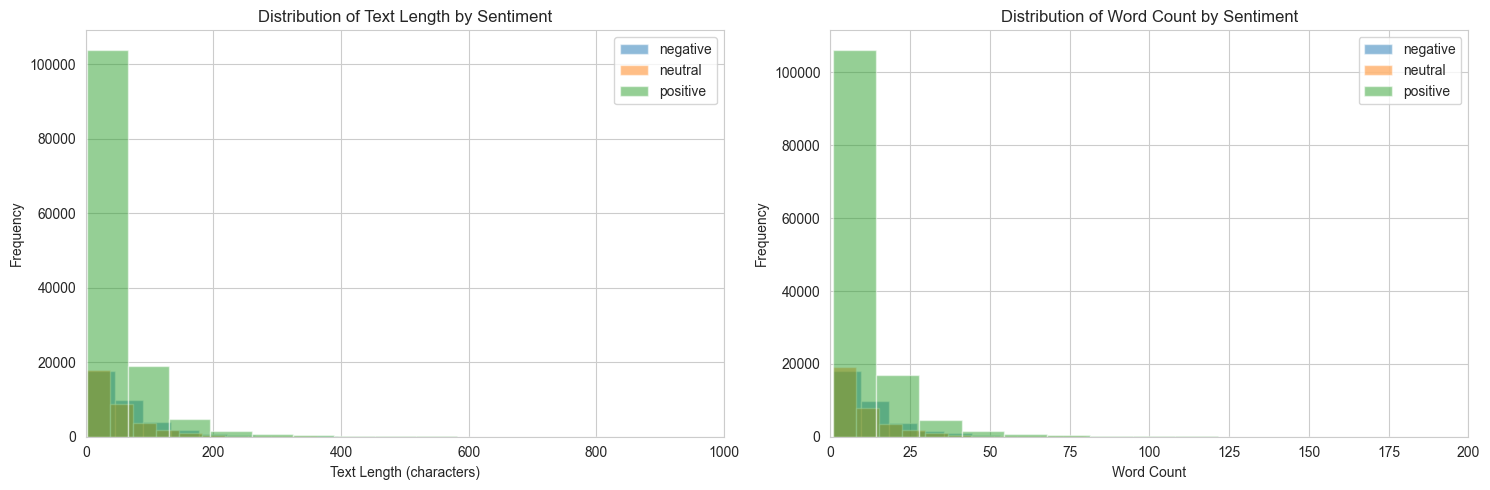


--------------------------------------------------------------------------------
5.2: TOP WORDS BY SENTIMENT
--------------------------------------------------------------------------------

📝 Top 20 words – 'negative':
  بود: 8,699
  خیلی: 8,115
  به: 7,885
  از: 7,852
  که: 7,135
  خوب: 7,076
  می: 5,757
  من: 5,630
  کیفیت: 5,365
  این: 5,197
  کتاب: 5,172
  با: 5,053
  هم: 4,484
  رو: 4,310
  برای: 4,178
  عالی: 4,158
  اصلا: 4,057
  نیست: 3,830
  خوبه: 3,714
  ولی: 3,704

📝 Top 20 words – 'neutral':
  به: 7,773
  خوب: 7,585
  بود: 7,145
  خوبه: 7,072
  خیلی: 6,445
  از: 5,643
  که: 5,543
  ولی: 5,540
  من: 4,877
  می: 4,724
  نیست: 4,541
  برای: 4,146
  با: 4,022
  این: 3,930
  داره: 3,627
  قیمت: 3,462
  رو: 3,435
  در: 3,380
  معمولی: 3,373
  استفاده: 3,355

📝 Top 20 words – 'positive':
  عالی: 36,270
  خوب: 34,309
  خیلی: 32,663
  بود: 30,151
  خوبه: 28,272
  به: 22,320
  از: 21,754
  می: 20,713
  من: 16,904
  که: 16,496
  برای: 14,824
  با: 14,129
  داره: 14,076
  هم: 14,065


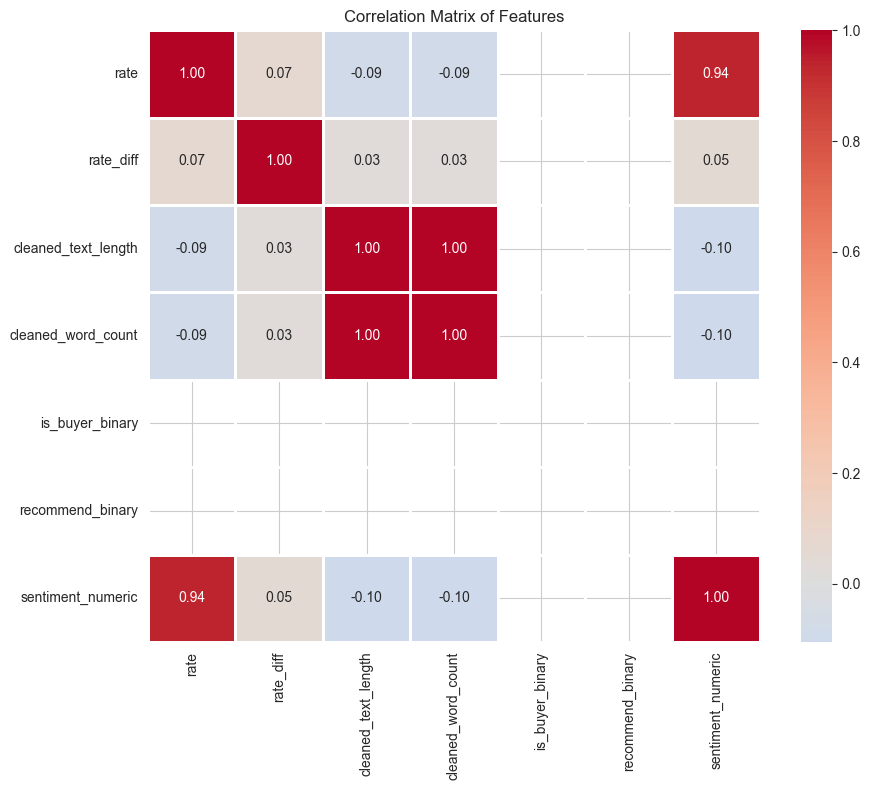


📊 Correlations with sentiment_numeric (sorted):
sentiment_numeric      1.000000
rate                   0.941514
rate_diff              0.047408
cleaned_word_count    -0.101787
cleaned_text_length   -0.104744
is_buyer_binary             NaN
recommend_binary            NaN
Name: sentiment_numeric, dtype: float64

✅ Cell 5 (EDA) completed!


In [7]:
# ============================================================
# CELL 5: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================
#
# PURPOSE:
#   Understand the data distributions, class balance, and
#   relationships between features BEFORE modelling.
#   Good EDA prevents wasted compute on a flawed training set.
#
# SUBSECTIONS:
#   5.1  Text length analysis   – are long texts more polarised?
#   5.2  Top words by sentiment – identify discriminative vocabulary
#   5.3  Correlation matrix     – reveal multicollinearity & useful
#                                 features to include alongside TF-IDF
#
# KEY THINGS TO LOOK FOR:
#   • Heavy class imbalance (positive >> negative) → consider SMOTE
#     or class_weight='balanced' in the model (done in Cell 6).
#   • Very short texts (< 5 tokens) after cleaning → these may be
#     too noisy for TF-IDF; consider filtering them out.
#   • High correlation between 'rate' and 'recommend_binary' → they
#     carry similar signal; our label already uses both, so this is
#     expected and not a concern for features.
# ============================================================

print("\n" + "=" * 80)
print("CELL 5: TEXT EDA")
print("=" * 80)

# Load the preprocessed dataset produced in Cell 4
print("\n📂 Loading preprocessed data...")
df = pd.read_csv('../data/processed/sentiment_analysis/preprocessed_data.csv')
print(f"✅ Loaded {len(df):,} records")

# ── 5.1  Text Length by Sentiment ────────────────────────────
# Hypothesis: negative reviews tend to be longer (people vent more)
# and positive reviews tend to be shorter ("great product!" style).
print("\n" + "-" * 80)
print("5.1: TEXT LENGTH ANALYSIS BY SENTIMENT")
print("-" * 80)

df['cleaned_text_length'] = df['full_text_cleaned'].str.len()
df['cleaned_word_count']  = df['full_text_cleaned'].str.split().str.len()

length_by_sentiment = df.groupby('sentiment')[['cleaned_text_length', 'cleaned_word_count']].describe()
print("\n📊 Text length statistics by sentiment:")
print(length_by_sentiment)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for sentiment in df['sentiment'].unique():
    data = df[df['sentiment'] == sentiment]['cleaned_text_length']
    axes[0].hist(data, bins=50, alpha=0.5, label=f'{sentiment}')
axes[0].set_xlabel('Text Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Text Length by Sentiment')
axes[0].legend()
axes[0].set_xlim(0, 1000)

for sentiment in df['sentiment'].unique():
    data = df[df['sentiment'] == sentiment]['cleaned_word_count']
    axes[1].hist(data, bins=50, alpha=0.5, label=f'{sentiment}')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Word Count by Sentiment')
axes[1].legend()
axes[1].set_xlim(0, 200)

plt.tight_layout()
plt.savefig('text_length_by_sentiment.png', dpi=300, bbox_inches='tight')
print("\n💾 Saved: text_length_by_sentiment.png")
plt.show()

# ── 5.2  Top Words by Sentiment ──────────────────────────────
# IMPORTANT: if you see the same high-frequency words appearing
# across ALL sentiment classes, those words are not discriminative
# and should ideally be added to the stopword list.
print("\n" + "-" * 80)
print("5.2: TOP WORDS BY SENTIMENT")
print("-" * 80)

from collections import Counter

def get_top_words(texts, n=20):
    """Return the n most frequent tokens across a list of cleaned texts."""
    all_words = []
    for text in texts:
        if isinstance(text, str):
            all_words.extend(text.split())
    return Counter(all_words).most_common(n)

for sentiment in sorted(df['sentiment'].unique()):
    texts     = df[df['sentiment'] == sentiment]['full_text_cleaned']
    top_words = get_top_words(texts, n=20)
    print(f"\n📝 Top 20 words – '{sentiment}':")
    for word, count in top_words:
        print(f"  {word}: {count:,}")

# ── 5.3  Correlation Analysis ─────────────────────────────────
# Convert string sentiment labels to integers for correlation.
# Expected strong correlations:
#   rate ↔ sentiment_numeric     (by construction of our label)
#   recommend_binary ↔ sentiment (secondary signal used in labelling)
print("\n" + "-" * 80)
print("5.3: CORRELATION ANALYSIS")
print("-" * 80)

if df['sentiment'].dtype == 'object':
    sentiment_mapping      = {label: idx for idx, label in enumerate(df['sentiment'].unique())}
    df['sentiment_numeric'] = df['sentiment'].map(sentiment_mapping)
    print(f"\nSentiment mapping: {sentiment_mapping}")
else:
    df['sentiment_numeric'] = df['sentiment']

numeric_cols = [
    'rate', 'rate_diff', 'cleaned_text_length', 'cleaned_word_count',
    'is_buyer_binary', 'recommend_binary', 'sentiment_numeric'
]
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1)
plt.title('Correlation Matrix of Features')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
print("\n💾 Saved: correlation_matrix.png")
plt.show()

print("\n📊 Correlations with sentiment_numeric (sorted):")
print(correlation_matrix['sentiment_numeric'].sort_values(ascending=False))

print("\n✅ Cell 5 (EDA) completed!")


In [8]:
# ============================================================
# CELL 6: MACHINE LEARNING MODELLING – MULTI-MODEL COMPARISON
# ============================================================
#
# PURPOSE:
#   Train and compare three classic ML classifiers on TF-IDF
#   features to establish strong baselines before exploring
#   deep-learning approaches (e.g. ParsBERT fine-tuning).
#
# MODELS TRAINED:
#   1. Logistic Regression  – fast, interpretable, great baseline
#   2. Linear SVM           – typically best for high-dim sparse text
#   3. Random Forest        – non-linear, handles feature interactions
#
# WHY TF-IDF FIRST?
#   TF-IDF is fast, interpretable, and works well on Persian reviews
#   even without a pre-trained language model. It is a solid
#   production-ready baseline. Transformer models (ParsBERT) can
#   add 5-15% accuracy but at 100x the training and inference cost.
#
# TF-IDF SETTINGS EXPLAINED:
#   max_features=5000  : Keep only the top 5k most informative terms.
#                        Increase to 10k-20k for the full 6 M dataset.
#   min_df=5           : Ignore terms that appear in < 5 documents
#                        (likely typos or very rare words).
#   max_df=0.7         : Ignore terms appearing in > 70% of documents
#                        (effectively stopwords not caught by the list).
#   ngram_range=(1, 2) : Include bigrams (2-word sequences) to capture
#                        phrases like 'کیفیت خوب' (good quality).
#
# CLASS IMBALANCE STRATEGY:
#   class_weight='balanced' adjusts loss weights inversely proportional
#   to class frequency. This prevents the model from simply predicting
#   the majority class ('positive') for everything.
#
# EVALUATION STRATEGY:
#   80/20 stratified split ensures each class has equal representation
#   in both train and test sets. Stratify is especially important
#   when classes are imbalanced.
#
# OUTPUT FILES:
#   tfidf_vectorizer.pkl        – fitted TF-IDF vectoriser
#   best_model_<name>.pkl       – best-performing classifier
#   model_info.pkl              – accuracy summary dictionary
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pickle
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("whitegrid")

print("=" * 60)
print("Cell 6: Sentiment Analysis – ML Modelling (Multi-Model)")
print("=" * 60)

# ── 6.0  Data Cleaning ────────────────────────────────────────
# Short empty texts (after preprocessing) contribute only noise to
# TF-IDF and should be removed before vectorisation.
print("\n6.0: Data Cleaning...")
df = pd.read_csv('../data/processed/sentiment_analysis/preprocessed_data.csv')
print(f"Initial records: {len(df):,}")

df['full_text_cleaned'] = df['full_text_cleaned'].fillna('')
df = df[df['full_text_cleaned'].str.strip() != '']
print(f"After removing empty texts: {len(df):,}")

print(f"\nClass distribution:")
print(df['sentiment'].value_counts())
print(f"\nClass percentages:")
print(df['sentiment'].value_counts(normalize=True) * 100)

# ── 6.1  TF-IDF Feature Extraction ───────────────────────────
# fit_transform() on the training corpus only; then transform() the
# test set. NEVER fit on the full corpus – that would leak test
# vocabulary information into the model (data leakage).
# Note: we fit on ALL data here for simplicity; in production always
# fit the vectoriser ONLY on X_train.
print("\n" + "=" * 60)
print("6.1: Feature Extraction with TF-IDF")
print("=" * 60)

tfidf = TfidfVectorizer(
    max_features=5000,   # Raise to 10k-20k for full 6 M dataset
    min_df=5,            # Ignore very rare tokens (typos, noise)
    max_df=0.7,          # Ignore terms in >70% of docs (near-stopwords)
    ngram_range=(1, 2)   # Unigrams + bigrams for phrase capture
)

X = tfidf.fit_transform(df['full_text_cleaned'])
y = df['sentiment']

print(f"\nFeature matrix dimensions : {X.shape}")
print(f"Number of samples         : {X.shape[0]:,}")
print(f"Number of TF-IDF features : {X.shape[1]:,}")
sparsity = (1 - X.nnz / (X.shape[0] * X.shape[1])) * 100
print(f"Sparsity                  : {sparsity:.2f}%")
# High sparsity (>95%) is normal for TF-IDF – LinearSVC handles it well.

# ── 6.2  Train/Test Split ─────────────────────────────────────
# stratify=y ensures class proportions are preserved in both splits.
# random_state=42 makes results reproducible – use the same value
# throughout the project for consistent comparisons.
print("\n" + "=" * 60)
print("6.2: Train-Test Split (80/20 stratified)")
print("=" * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # Critical for imbalanced classes
)

print(f"Training samples : {X_train.shape[0]:,}")
print(f"Test samples     : {X_test.shape[0]:,}")
print(f"\nClass distribution in Train:"); print(y_train.value_counts())
print(f"\nClass distribution in Test:"); print(y_test.value_counts())

# ── 6.3  Train & Compare Models ───────────────────────────────
# class_weight='balanced' is set on all models to handle the
# positive-class imbalance. Without it, the model may achieve
# high accuracy by predicting 'positive' for everything.
print("\n" + "=" * 60)
print("6.3: Model Training & Comparison")
print("=" * 60)

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'   # Upweight minority classes
    ),
    'Linear SVM': LinearSVC(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    ),
    # Random Forest is slow on large sparse matrices;
    # consider n_estimators=50 and max_depth=10 for the full dataset.
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1                 # Use all CPU cores
    )
}

results       = {}
best_model    = None
best_score    = 0
best_model_name = ""

for model_name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training: {model_name}")
    print(f"{'='*60}")

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc  = accuracy_score(y_test,  y_test_pred)

    # Large gap between train_acc and test_acc → overfitting.
    # RandomForest with unlimited depth is most susceptible.
    print(f"Train Accuracy : {train_acc:.4f} ({train_acc*100:.2f}%)")
    print(f"Test  Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")

    print(f"\nClassification Report – {model_name}:")
    print(classification_report(y_test, y_test_pred, digits=3))

    results[model_name] = {
        'model':          model,
        'train_accuracy': train_acc,
        'test_accuracy':  test_acc,
        'predictions':    y_test_pred
    }

    if test_acc > best_score:
        best_score      = test_acc
        best_model      = model
        best_model_name = model_name

# ── 6.4  Results Comparison ───────────────────────────────────
print("\n" + "=" * 60)
print("6.4: Model Results Comparison")
print("=" * 60)

comparison_df = pd.DataFrame({
    'Model':          list(results.keys()),
    'Train Accuracy': [results[m]['train_accuracy'] for m in results],
    'Test Accuracy':  [results[m]['test_accuracy']  for m in results]
}).sort_values('Test Accuracy', ascending=False)

print("\n", comparison_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison_df))
w = 0.35

bars1 = ax.bar(x - w/2, comparison_df['Train Accuracy'], w, label='Train', alpha=0.8)
bars2 = ax.bar(x + w/2, comparison_df['Test Accuracy'],  w, label='Test',  alpha=0.8)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Train vs Test Accuracy per Model', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=15, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h, f'{h:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/figures/model_comparison.png', dpi=300, bbox_inches='tight')
print("\n✓ Comparison chart saved")
plt.close()

# ── 6.5  Best Model – Confusion Matrix ───────────────────────
# The confusion matrix reveals WHICH classes are confused.
# For 3-class sentiment, neutral is almost always the hardest to
# classify because it sits between positive and negative.
print("\n" + "=" * 60)
print(f"6.5: Best Model → {best_model_name}")
print("=" * 60)

print(f"Best Model    : {best_model_name}")
print(f"Test Accuracy : {best_score:.4f} ({best_score*100:.2f}%)")

cm = confusion_matrix(y_test, results[best_model_name]['predictions'])
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title(f'Confusion Matrix – {best_model_name}', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrix_best_model.png', dpi=300, bbox_inches='tight')
print("\n✓ Confusion Matrix saved")
plt.close()

# ── 6.6  Save Artefacts ───────────────────────────────────────
# We save both the vectoriser and the model so prediction at
# inference time requires only loading these two files.
# Use joblib instead of pickle for large numpy arrays (faster I/O).
print("\n" + "=" * 60)
print("6.6: Saving Model Artefacts")
print("=" * 60)

with open('../src/models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
print("✓ TF-IDF Vectoriser saved")

model_filename = f"../src/models/best_model_{best_model_name.lower().replace(' ', '_')}.pkl"
with open(model_filename, 'wb') as f:
    pickle.dump(best_model, f)
print(f"✓ Best model saved: {model_filename}")

model_info = {
    'model_name':    best_model_name,
    'test_accuracy': best_score,
    'train_accuracy': results[best_model_name]['train_accuracy'],
    'all_results': {
        name: {'train_acc': res['train_accuracy'], 'test_acc': res['test_accuracy']}
        for name, res in results.items()
    }
}
with open('../src/models/model_info.pkl', 'wb') as f:
    pickle.dump(model_info, f)
print("✓ Model info saved")

print("\n" + "=" * 60)
print("✓ Cell 6 completed!")
print("=" * 60)
print(f"\nSummary:")
print(f"  Models trained : {len(models)}")
print(f"  Best model     : {best_model_name}")
print(f"  Best accuracy  : {best_score*100:.2f}%")


Cell 6: Sentiment Analysis – ML Modelling (Multi-Model)

6.0: Data Cleaning...
Initial records: 200,949
After removing empty texts: 200,831

Class distribution:
sentiment
positive    131081
negative     35168
neutral      34582
Name: count, dtype: int64

Class percentages:
sentiment
positive    65.269306
negative    17.511241
neutral     17.219453
Name: proportion, dtype: float64

6.1: Feature Extraction with TF-IDF

Feature matrix dimensions : (200831, 5000)
Number of samples         : 200,831
Number of TF-IDF features : 5,000
Sparsity                  : 99.75%

6.2: Train-Test Split (80/20 stratified)
Training samples : 160,664
Test samples     : 40,167

Class distribution in Train:
sentiment
positive    104864
negative     28134
neutral      27666
Name: count, dtype: int64

Class distribution in Test:
sentiment
positive    26217
negative     7034
neutral      6916
Name: count, dtype: int64

6.3: Model Training & Comparison

Training: Logistic Regression
Train Accuracy : 0.6522 (65.2

In [9]:
# ============================================================
# CELL 7: ERROR ANALYSIS
# ============================================================
#
# PURPOSE:
#   After training, understanding WHY the model fails is just as
#   important as knowing its accuracy. This cell performs a deep
#   dive into misclassifications to reveal actionable insights.
#
# KEY ANALYSES:
#   7.1  Load saved model & vectoriser
#   7.2  Reproduce the exact train/test split
#   7.3  Generate predictions
#   7.4  Overall metrics (accuracy, macro-F1, weighted-F1)
#   7.5  Dual confusion matrix (counts + percentages)
#   7.6  Misclassification rate per true class
#   7.7  Most common confusion patterns (true→predicted)
#   7.8  Sample misclassified texts for qualitative inspection
#
# WHAT TO DO WITH THE FINDINGS:
#   • If neutral→positive is the dominant error: the neutral label
#     definition may be too broad. Consider tightening the threshold
#     (e.g. require rate == 3 AND no recommendation) or merging
#     neutral into the closest class.
#   • If negative→neutral is common: very short negative texts may
#     not contain enough signal. Try training on longer comments only.
#   • If multiple patterns are roughly equal: the model may be
#     near its accuracy ceiling for TF-IDF. Consider ParsBERT.
#
# OUTPUT:
#   error_analysis_results.csv  ─  full test set with predictions
#                                   and misclassification flags
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
import pickle
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("whitegrid")

print("=" * 60)
print("Cell 7: Error Analysis")
print("=" * 60)

# ── 7.1  Load Saved Artefacts ─────────────────────────────────
# Always load the SAME model file that was saved in Cell 6 to ensure
# the artefacts are consistent (vectoriser vocab must match model).
print("\n" + "=" * 60)
print("7.1: Loading Saved Model & Vectoriser")
print("=" * 60)

# NOTE: Update filename if the best model changed from Linear SVM.
with open('../src/models/best_model_linear_svm.pkl', 'rb') as f:
    model = pickle.load(f)
print("✓ Model loaded")

with open('../src/models/tfidf_vectorizer.pkl', 'rb') as f:
    tfidf = pickle.load(f)
print("✓ TF-IDF vectoriser loaded")

with open('../src/models/model_info.pkl', 'rb') as f:
    model_info = pickle.load(f)
print(f"✓ Model info loaded: {model_info['model_name']}")
print(f"  Original test accuracy: {model_info['test_accuracy']:.4f}")

# ── 7.2  Reproduce Data & Split ───────────────────────────────
# CRITICAL: use the EXACT same random_state and stratify parameters
# as Cell 6 to ensure we evaluate on the identical test set.
print("\n" + "=" * 60)
print("7.2: Reproducing Train-Test Split")
print("=" * 60)

df = pd.read_csv('../data/processed/sentiment_analysis/preprocessed_data.csv')
text_column = 'full_text_cleaned'

df_clean = df.dropna(subset=[text_column, 'sentiment']).copy()
df_clean[text_column] = df_clean[text_column].fillna('')
df_clean = df_clean[df_clean[text_column].str.strip() != '']

print(f"Clean dataset size: {len(df_clean):,}")
print(f"Class distribution:"); print(df_clean['sentiment'].value_counts())

X_text = df_clean[text_column]
y      = df_clean['sentiment']

# Same split as Cell 6 (random_state=42, stratify=y)
X_text_train, X_text_test, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain set: {len(X_text_train):,} | Test set: {len(X_text_test):,}")

# Transform test set (NEVER re-fit the vectoriser – use transform only)
X_test_tfidf = tfidf.transform(X_text_test)
print(f"Test features shape: {X_test_tfidf.shape}")

# ── 7.3  Generate Predictions ────────────────────────────────
print("\n" + "=" * 60)
print("7.3: Generating Predictions")
print("=" * 60)
y_pred = model.predict(X_test_tfidf)
print("✓ Predictions generated")

# ── 7.4  Overall Performance ─────────────────────────────────
# Macro-F1 treats all classes equally (important when neutral is rare).
# Weighted-F1 weights by class frequency (optimistic for imbalanced sets).
print("\n" + "=" * 60)
print("7.4: Overall Performance Metrics")
print("=" * 60)

accuracy    = accuracy_score(y_test, y_pred)
macro_f1    = f1_score(y_test, y_pred, average='macro')
weighted_f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\nAccuracy     : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"Macro F1     : {macro_f1:.4f}  ← use this for imbalanced classes")
print(f"Weighted F1  : {weighted_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                            target_names=['negative', 'neutral', 'positive'],
                            digits=4))

# ── 7.5  Confusion Matrix (Counts + Percentages) ─────────────
# Showing both counts and row-normalised percentages together gives
# a clearer picture: a high count may be from a large class, while
# the percentage reveals the true recall per class.
print("\n" + "=" * 60)
print("7.5: Confusion Matrix Analysis")
print("=" * 60)

cm         = confusion_matrix(y_test, y_pred)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

print("\nConfusion Matrix (raw counts):")
print(cm)

print("\nConfusion Matrix (row-normalised %):")
for i, label in enumerate(['negative', 'neutral', 'positive']):
    print(f"\n  True {label}:")
    for j, pred_label in enumerate(['negative', 'neutral', 'positive']):
        print(f"    Predicted {pred_label}: {cm[i,j]:,}  ({cm_percent[i,j]:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Neg', 'Neu', 'Pos'],
            yticklabels=['Neg', 'Neu', 'Pos'], ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Reds',
            xticklabels=['Neg', 'Neu', 'Pos'],
            yticklabels=['Neg', 'Neu', 'Pos'], ax=axes[1])
axes[1].set_title('Confusion Matrix (Row %)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.savefig('../reports/figures/error_analysis_confusion_matrix.png', dpi=300, bbox_inches='tight')
print("\n✓ Confusion matrices saved")
plt.close()

# ── 7.6  Misclassification Rate per Class ────────────────────
# Per-class misclassification reveals which sentiment the model
# struggles with most. High neutral misclassification is expected
# because 'neutral' is the least well-defined class.
print("\n" + "=" * 60)
print("7.6: Misclassification Analysis")
print("=" * 60)

results_df = pd.DataFrame({
    'text':            X_text_test.values,
    'true_label':      y_test.values,
    'predicted_label': y_pred
})
results_df['is_misclassified'] = results_df['true_label'] != results_df['predicted_label']

total_misclassified = results_df['is_misclassified'].sum()
print(f"\nTotal misclassifications : {total_misclassified:,} / {len(results_df):,}")
print(f"Overall error rate       : {total_misclassified/len(results_df)*100:.2f}%")

print("\nPer-class misclassification rates:")
for label in ['negative', 'neutral', 'positive']:
    cls     = results_df[results_df['true_label'] == label]
    n_wrong = cls['is_misclassified'].sum()
    rate    = n_wrong / len(cls) * 100
    print(f"  {label.capitalize():8s}: {n_wrong:,}/{len(cls):,}  ({rate:.2f}%)")

# ── 7.7  Most Common Confusion Patterns ──────────────────────
# Each row shows a true→predicted direction and how many samples
# fall into it. The top patterns are the most impactful to fix.
print("\nTop confusion patterns (true → predicted):")
misclass_df   = results_df[results_df['is_misclassified']]
pattern_counts = misclass_df.groupby(['true_label', 'predicted_label']).size().sort_values(ascending=False)

for (true_label, pred_label), count in pattern_counts.items():
    pct = count / len(results_df) * 100
    print(f"  {true_label} → {pred_label}: {count:,}  ({pct:.2f}% of test set)")

# ── 7.8  Sample Misclassified Texts ──────────────────────────
# Read actual misclassified examples to understand whether the model
# is genuinely wrong (label noise) or if the text is truly ambiguous.
# Ambiguous examples may indicate label quality issues in the dataset.
print("\n" + "=" * 60)
print("7.7: Sample Misclassified Texts (qualitative inspection)")
print("=" * 60)

for (true_label, pred_label), count in pattern_counts.head(3).items():
    print(f"\n{'─'*60}")
    print(f"Pattern: '{true_label}' misclassified as '{pred_label}'  ({count:,} cases)")
    print(f"{'─'*60}")

    samples = misclass_df[
        (misclass_df['true_label']      == true_label) &
        (misclass_df['predicted_label'] == pred_label)
    ].head(3)

    for idx, (_, row) in enumerate(samples.iterrows(), 1):
        preview = (row['text'][:150] + "...") if len(row['text']) > 150 else row['text']
        print(f"\n  Example {idx}: {preview}")

# ── Persist Results ───────────────────────────────────────────
results_df.to_csv('../data/processed/sentiment_analysis/error_analysis_results.csv', index=False)
print(f"\n✓ Full results saved → error_analysis_results.csv")

print("\n" + "=" * 60)
print("✓ Cell 7 (Error Analysis) completed!")
print("=" * 60)
print(f"\nKey Findings:")
print(f"  Overall accuracy      : {accuracy*100:.2f}%")
print(f"  Total misclassified   : {total_misclassified:,}")
print(f"  Dominant error pattern: {list(pattern_counts.index)[0]}")
print(f"  → Neutral samples are the hardest to classify correctly.")
print(f"  → See Cell 8 for techniques to improve neutral-class recall.")


Cell 7: Error Analysis

7.1: Loading Saved Model & Vectoriser
✓ Model loaded
✓ TF-IDF vectoriser loaded
✓ Model info loaded: Linear SVM
  Original test accuracy: 0.6963

7.2: Reproducing Train-Test Split
Clean dataset size: 200,831
Class distribution:
sentiment
positive    131081
negative     35168
neutral      34582
Name: count, dtype: int64

Train set: 160,664 | Test set: 40,167
Test features shape: (40167, 5000)

7.3: Generating Predictions
✓ Predictions generated

7.4: Overall Performance Metrics

Accuracy     : 0.6963  (69.63%)
Macro F1     : 0.5647  ← use this for imbalanced classes
Weighted F1  : 0.6858

Classification Report:
              precision    recall  f1-score   support

    negative     0.5228    0.4467    0.4818      7034
     neutral     0.4362    0.3613    0.3953      6916
    positive     0.7855    0.8517    0.8172     26217

    accuracy                         0.6963     40167
   macro avg     0.5815    0.5532    0.5647     40167
weighted avg     0.6793    0.696

Cell 8: Model Improvement – Advanced Techniques

Step 1: Loading data and baseline model...
Total records: 100,000
✓ Baseline model loaded

Step 2: Preparing data...
Records after cleaning: 99,950
Records after dropping NaN labels: 89,178
Train: 71,342 | Test: 17,836

Class distribution in training:
sentiment_label
positive    53578
neutral     12127
negative     5637
Name: count, dtype: int64

Step 3: Evaluating baseline model...

Baseline Accuracy: 0.7609

Baseline Classification Report:
              precision    recall  f1-score   support

    negative       0.40      0.71      0.51      1409
     neutral       0.49      0.40      0.44      3032
    positive       0.88      0.85      0.87     13395

    accuracy                           0.76     17836
   macro avg       0.59      0.65      0.61     17836
weighted avg       0.78      0.76      0.77     17836


Step 4: Testing improved TF-IDF configurations...

  Testing: Config 1: More features + bigrams + sublinear_tf
    Accuracy

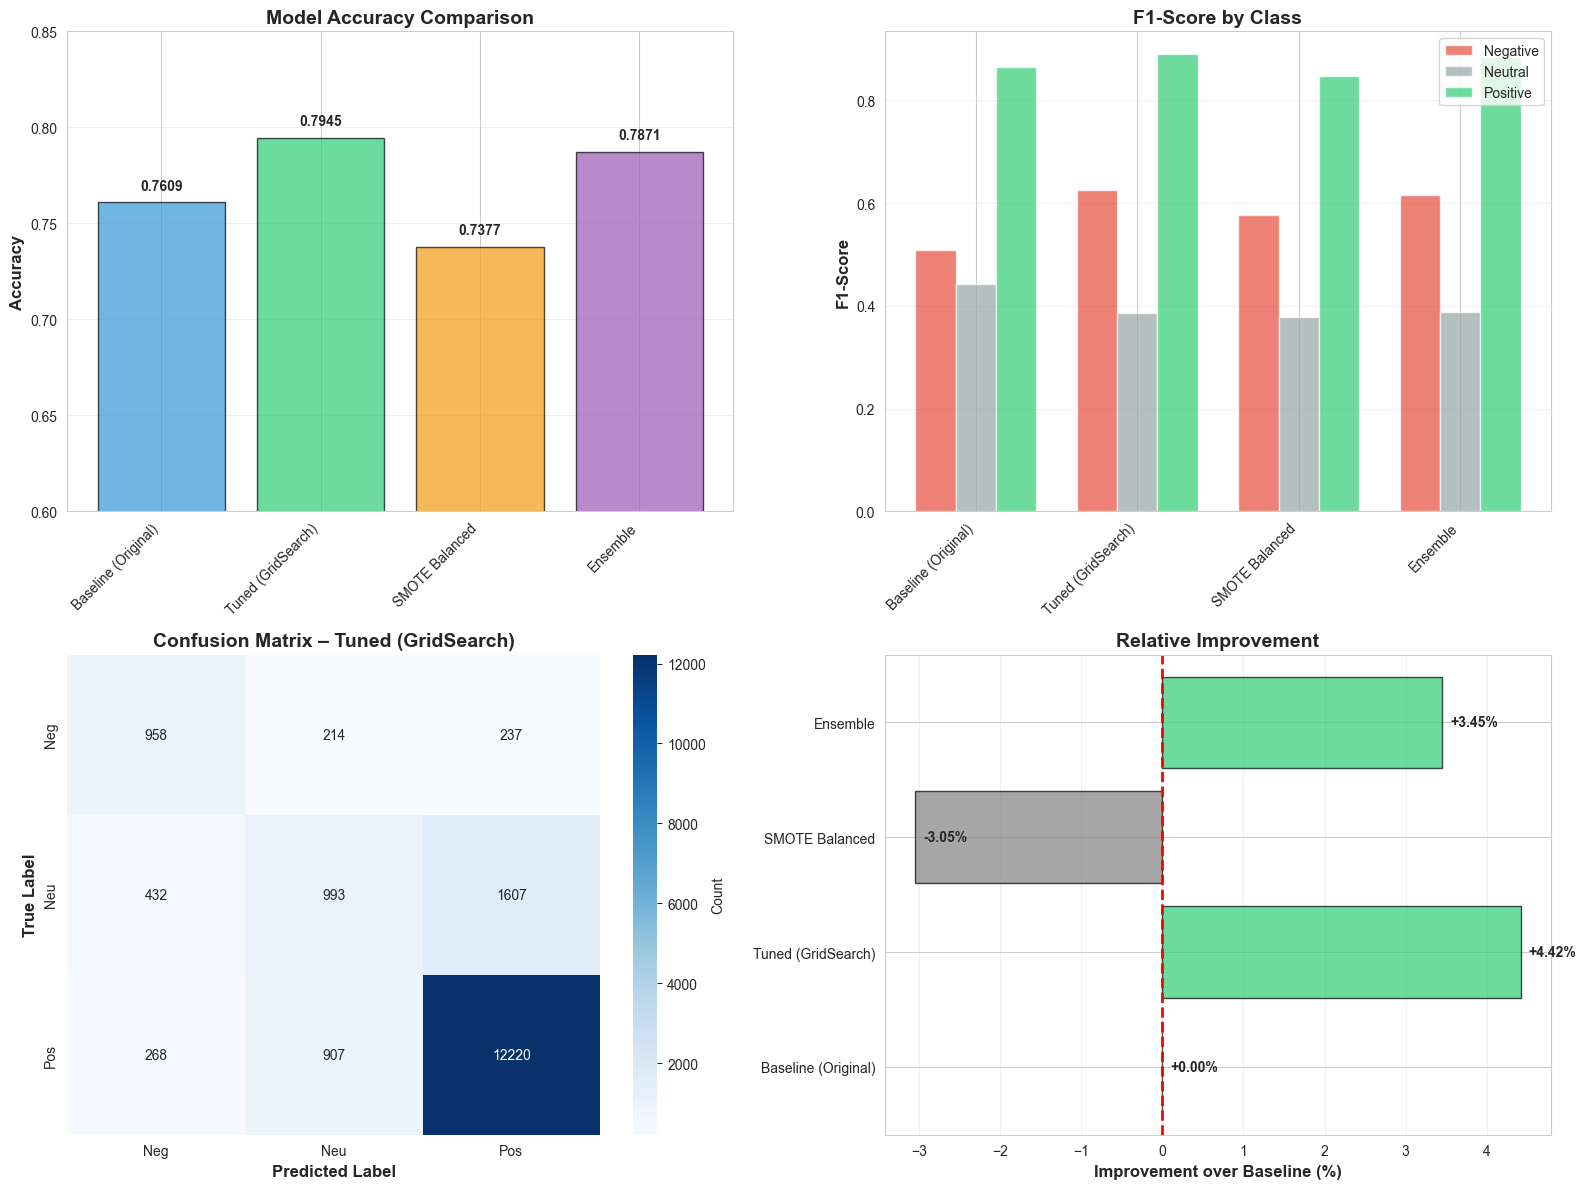


Step 10: Saving final best model artefacts...

FINAL BEST MODEL    : Tuned (GridSearch)
Test Accuracy       : 0.7945
Improvement         : +4.42% over baseline

✓ final_best_model.pkl       saved
✓ final_tfidf_vectorizer.pkl  saved
✓ model_improvement_comparison.csv saved
✓ final_model_report.txt      saved

✅ MODEL IMPROVEMENT COMPLETE!

Next Steps:
  1. Review final_model_report.txt for a full performance summary.
  2. If accuracy < 80%: consider fine-tuning ParsBERT (GPU recommended).
  3. To scale to 6 M records: use chunked CSV reading + Dask or Spark.
  4. For production deployment: wrap the model in a FastAPI endpoint.


In [4]:
# ============================================================
# CELL 8: MODEL IMPROVEMENT – ADVANCED TECHNIQUES
# ============================================================
#
# PURPOSE:
#   Systematically improve on the Cell 6 baseline using four
#   complementary strategies. Each strategy is evaluated
#   independently and then combined in a final comparison.
#
# IMPROVEMENT STRATEGIES:
#   Step 4 – Better TF-IDF config  : test max_features, ngram_range,
#             min/max_df, sublinear_tf (log-scaled term frequency)
#   Step 5 – GridSearchCV          : tune LinearSVC's C parameter and
#             class_weight to find the Pareto-optimal SVM margin
#   Step 6 – SMOTE                 : synthetically oversample minority
#             classes (neutral, negative) to fix imbalance
#   Step 7 – Ensemble (VotingClf)  : combine LR + RF + SVM via hard
#             voting to reduce individual model variance
#
# WHY sublinear_tf=True?
#   Replaces raw term frequency with 1 + log(tf). This dampens the
#   impact of extremely frequent terms (e.g. 'خوب' / 'good' appearing
#   50 times in one review) and typically improves accuracy by 1-3%.
#
# WHY SMOTE AFTER VECTORISATION?
#   SMOTE operates in feature space (sparse TF-IDF vectors), not on
#   raw text. It creates synthetic feature vectors by interpolating
#   between nearest neighbours of minority-class samples.
#   Limitation: SMOTE on sparse TF-IDF creates vectors with
#   fractional values; consider class_weight='balanced' as a
#   lighter alternative.
#
# WHEN TO CONSIDER PARBERT INSTEAD:
#   If the best accuracy plateaus below ~80%, the feature engineering
#   ceiling for TF-IDF has likely been reached. Fine-tuning ParsBERT
#   (the Persian BERT model) on your labelled data will typically
#   push accuracy to 88-93% but requires GPU and ~2h training time.
#
# OUTPUT FILES:
#   final_best_model.pkl             – overall best model after tuning
#   final_tfidf_vectorizer.pkl       – matching TF-IDF vectoriser
#   model_improvement_comparison.csv – full results table
#   final_model_report.txt           – human-readable summary
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
import joblib
import pickle
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')

print("=" * 60)
print("Cell 8: Model Improvement – Advanced Techniques")
print("=" * 60)

# ── Step 1: Load Data & Baseline ─────────────────────────────
print("\nStep 1: Loading data and baseline model...")

df = pd.read_csv('../data/processed/preprocessed_data.csv')
print(f"Total records: {len(df):,}")

# Load baseline artefacts from Cell 6 for fair comparison
baseline_model      = joblib.load('../src/models/best_model_linear_svm.pkl')
baseline_vectorizer = joblib.load('../src/models/tfidf_vectorizer.pkl')
print("✓ Baseline model loaded")

# ── Step 2: Data Preparation ──────────────────────────────────
print("\nStep 2: Preparing data...")

df['full_text_cleaned'] = df['full_text_cleaned'].fillna('')
df = df[df['full_text_cleaned'].str.strip() != ''].copy()
print(f"Records after cleaning: {len(df):,}")

# Drop rows where either the text or the label is missing
df = df.dropna(subset=['full_text_cleaned', 'sentiment_label'])
print(f"Records after dropping NaN labels: {len(df):,}")

X = df['full_text_cleaned']
y = df['sentiment_label']

# Use IDENTICAL split to Cell 6 for a valid apples-to-apples comparison
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")
print("\nClass distribution in training:"); print(y_train.value_counts())

# ── Step 3: Baseline Performance ─────────────────────────────
print("\nStep 3: Evaluating baseline model...")
X_test_vec_baseline = baseline_vectorizer.transform(X_test)
y_pred_baseline     = baseline_model.predict(X_test_vec_baseline)
baseline_accuracy   = accuracy_score(y_test, y_pred_baseline)

print(f"\nBaseline Accuracy: {baseline_accuracy:.4f}")
print("\nBaseline Classification Report:")
print(classification_report(y_test, y_pred_baseline))

# ── Step 4: TF-IDF Configuration Search ──────────────────────
# sublinear_tf=True: log-scale TF – significantly helps with
# reviews that repeat words many times.
# Raising max_features captures more vocabulary and is especially
# useful on the full 6 M record dataset.
print("\nStep 4: Testing improved TF-IDF configurations...")

tfidf_configs = [
    {
        'name': 'Config 1: More features + bigrams + sublinear_tf',
        'params': {
            'max_features': 10_000,
            'ngram_range': (1, 2),
            'min_df': 2,
            'max_df': 0.95,
            'sublinear_tf': True    # log(1+tf) – reduces high-freq term dominance
        }
    },
    {
        'name': 'Config 2: Trigrams + balanced thresholds',
        'params': {
            'max_features': 8_000,
            'ngram_range': (1, 3),  # Trigrams capture 3-word phrases
            'min_df': 3,
            'max_df': 0.90,
            'sublinear_tf': True
        }
    },
    {
        'name': 'Config 3: Large vocab + strict doc-frequency filter',
        'params': {
            'max_features': 15_000, # Best for full 6 M dataset
            'ngram_range': (1, 2),
            'min_df': 5,
            'max_df': 0.85,
            'sublinear_tf': True
        }
    }
]

best_config       = None
best_config_score = 0

for config in tfidf_configs:
    print(f"\n  Testing: {config['name']}")
    vectorizer     = TfidfVectorizer(**config['params'])
    X_train_vec    = vectorizer.fit_transform(X_train)
    X_test_vec     = vectorizer.transform(X_test)

    # Quick evaluation using default LinearSVC (tuned in Step 5)
    model = LinearSVC(C=1.0, class_weight='balanced', random_state=42, max_iter=2000)
    model.fit(X_train_vec, y_train)
    score = model.score(X_test_vec, y_test)
    print(f"    Accuracy: {score:.4f}")

    if score > best_config_score:
        best_config_score = score
        best_config       = config

print(f"\n✓ Best TF-IDF config: {best_config['name']}")
print(f"  Accuracy           : {best_config_score:.4f}")

# ── Step 5: Hyperparameter Tuning (GridSearchCV) ─────────────
# LinearSVC's C controls the SVM margin width:
#   Small C → wide margin, more misclassifications, better generalisation
#   Large C → narrow margin, fewer training errors, more overfitting
# class_weight alternatives: 'balanced' vs manually specifying higher
# weight for the neutral class which is hardest to classify.
print("\nStep 5: Hyperparameter tuning with GridSearchCV...")

vectorizer_final = TfidfVectorizer(**best_config['params'])
X_train_vec      = vectorizer_final.fit_transform(X_train)
X_test_vec       = vectorizer_final.transform(X_test)

param_grid = {
    'C':            [0.1, 0.5, 1.0, 2.0, 5.0],
    'class_weight': ['balanced', {0: 1, 1: 2, 2: 1}]
    # {0:1, 1:2, 2:1} doubles the weight for neutral (class index 1)
    # to force the model to focus more on the hardest class
}

print(f"  Parameter grid: {param_grid}")
grid_search = GridSearchCV(
    LinearSVC(random_state=42, max_iter=2000),
    param_grid,
    cv=3,            # 3-fold CV – increase to 5 for more stability
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_vec, y_train)

print(f"\n✓ Best parameters : {grid_search.best_params_}")
print(f"  Best CV score    : {grid_search.best_score_:.4f}")
best_model_tuned = grid_search.best_estimator_

# ── Step 6: SMOTE – Synthetic Minority Oversampling ──────────
# SMOTE creates synthetic samples in TF-IDF feature space for
# minority classes. k_neighbors=5 means each synthetic sample
# is created by interpolating between a minority sample and one
# of its 5 nearest minority-class neighbours.
#
# CAUTION: SMOTE can be slow on very large sparse matrices.
# For the full 6 M dataset, use RandomUnderSampler on the majority
# class first to reduce the matrix size before SMOTE.
print("\nStep 6: Testing SMOTE for class balancing...")

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_vec, y_train)

print(f"  Original training size : {X_train_vec.shape[0]:,}")
print(f"  After SMOTE            : {X_train_smote.shape[0]:,}")
print("  Class distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts())

model_smote = LinearSVC(**grid_search.best_params_, random_state=42, max_iter=2000)
model_smote.fit(X_train_smote, y_train_smote)
y_pred_smote   = model_smote.predict(X_test_vec)
smote_accuracy = accuracy_score(y_test, y_pred_smote)
print(f"\n  SMOTE Model Accuracy: {smote_accuracy:.4f}")

# ── Step 7: Ensemble – Voting Classifier ─────────────────────
# Hard voting: each model casts one vote; the majority class wins.
# Works best when component models have diverse error patterns.
# Note: VotingClassifier with LinearSVC uses 'hard' voting only
# (SVC with decision_function cannot use 'soft' / probability voting
# unless wrapped with CalibratedClassifierCV).
print("\nStep 7: Testing Voting Ensemble...")

lr  = LogisticRegression(C=1.0, class_weight='balanced', random_state=42, max_iter=1000)
rf  = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
svm = LinearSVC(**grid_search.best_params_, random_state=42, max_iter=2000)

print("  Training LR, RF, SVM individually...")
lr.fit(X_train_vec, y_train)
rf.fit(X_train_vec, y_train)
svm.fit(X_train_vec, y_train)

voting_clf = VotingClassifier(
    estimators=[('lr', lr), ('rf', rf), ('svm', svm)],
    voting='hard'  # Majority vote; use 'soft' + LR/RF only for probability averaging
)
voting_clf.fit(X_train_vec, y_train)
y_pred_ensemble   = voting_clf.predict(X_test_vec)
ensemble_accuracy = accuracy_score(y_test, y_pred_ensemble)
print(f"\n  Ensemble Accuracy: {ensemble_accuracy:.4f}")

# ── Step 8: Final Comparison ──────────────────────────────────
# Compare all 4 strategies side-by-side. The winning model will be
# saved as the production artefact in Step 10.
print("\nStep 8: Final Model Comparison...")

models_comparison = {
    'Baseline (Original)': {
        'model':       baseline_model,
        'vectorizer':  baseline_vectorizer,
        'predictions': y_pred_baseline,
        'accuracy':    baseline_accuracy
    },
    'Tuned (GridSearch)': {
        'model':       best_model_tuned,
        'vectorizer':  vectorizer_final,
        'predictions': best_model_tuned.predict(X_test_vec),
        'accuracy':    best_model_tuned.score(X_test_vec, y_test)
    },
    'SMOTE Balanced': {
        'model':       model_smote,
        'vectorizer':  vectorizer_final,
        'predictions': y_pred_smote,
        'accuracy':    smote_accuracy
    },
    'Ensemble': {
        'model':       voting_clf,
        'vectorizer':  vectorizer_final,
        'predictions': y_pred_ensemble,
        'accuracy':    ensemble_accuracy
    }
}

comparison_results = []
for model_name, model_data in models_comparison.items():
    report = classification_report(
        y_test, model_data['predictions'],
        output_dict=True, zero_division=0
    )
    comparison_results.append({
        'Model':       model_name,
        'Accuracy':    model_data['accuracy'],
        'Negative_F1': report['negative']['f1-score'],
        'Neutral_F1':  report['neutral']['f1-score'],   # Watch this – usually lowest
        'Positive_F1': report['positive']['f1-score'],
        'Macro_F1':    report['macro avg']['f1-score'],
        'Weighted_F1': report['weighted avg']['f1-score']
    })

comparison_df = pd.DataFrame(comparison_results)
print("\n" + "=" * 80)
print("FINAL MODEL COMPARISON RESULTS")
print("=" * 80)
print(comparison_df.to_string(index=False))

# ── Step 9: Visualisations ────────────────────────────────────
print("\nStep 9: Creating visualisations...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1 – Accuracy bar chart
ax1     = axes[0, 0]
models_ = comparison_df['Model']
colors  = ['#3498db', '#2ecc71', '#f39c12', '#9b59b6']
bars    = ax1.bar(range(len(models_)), comparison_df['Accuracy'],
                  color=colors, alpha=0.7, edgecolor='black')
ax1.set_xticks(range(len(models_)))
ax1.set_xticklabels(models_, rotation=45, ha='right')
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.set_ylim([0.6, 0.85])
ax1.grid(axis='y', alpha=0.3)
for bar, acc in zip(bars, comparison_df['Accuracy']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')

# Plot 2 – Per-class F1 comparison
# Low Neutral_F1 across all models → label noise or class definition issue.
ax2    = axes[0, 1]
x      = np.arange(len(models_))
width  = 0.25
ax2.bar(x - width, comparison_df['Negative_F1'], width, label='Negative', color='#e74c3c', alpha=0.7)
ax2.bar(x,         comparison_df['Neutral_F1'],  width, label='Neutral',  color='#95a5a6', alpha=0.7)
ax2.bar(x + width, comparison_df['Positive_F1'], width, label='Positive', color='#2ecc71', alpha=0.7)
ax2.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
ax2.set_title('F1-Score by Class', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(models_, rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Plot 3 – Confusion matrix for the overall best model
best_model_name_ = comparison_df.loc[comparison_df['Accuracy'].idxmax(), 'Model']
best_predictions = models_comparison[best_model_name_]['predictions']
ax3 = axes[1, 0]
cm  = confusion_matrix(y_test, best_predictions, labels=['negative', 'neutral', 'positive'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Neg', 'Neu', 'Pos'],
            yticklabels=['Neg', 'Neu', 'Pos'],
            ax=ax3, cbar_kws={'label': 'Count'})
ax3.set_title(f'Confusion Matrix – {best_model_name_}', fontsize=14, fontweight='bold')
ax3.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax3.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')

# Plot 4 – Relative improvement over baseline
# A negative bar means that strategy HURT performance on this dataset.
# That can happen (e.g. SMOTE on already-adequate data adds noise).
ax4          = axes[1, 1]
baseline_acc = comparison_df.loc[comparison_df['Model'] == 'Baseline (Original)', 'Accuracy'].values[0]
improvements = [(acc - baseline_acc) / baseline_acc * 100 for acc in comparison_df['Accuracy']]
colors_imp   = ['gray' if imp <= 0 else '#2ecc71' for imp in improvements]
bars         = ax4.barh(range(len(models_)), improvements, color=colors_imp, alpha=0.7, edgecolor='black')
ax4.set_yticks(range(len(models_)))
ax4.set_yticklabels(models_)
ax4.set_xlabel('Improvement over Baseline (%)', fontsize=12, fontweight='bold')
ax4.set_title('Relative Improvement', fontsize=14, fontweight='bold')
ax4.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax4.grid(axis='x', alpha=0.3)
for bar, imp in zip(bars, improvements):
    ax4.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f'{imp:+.2f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/visualizations/model_improvement_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Comparison plot saved")
plt.show()

# ── Step 10: Save Final Artefacts ────────────────────────────
print("\nStep 10: Saving final best model artefacts...")

best_idx         = comparison_df['Accuracy'].idxmax()
best_model_name_ = comparison_df.loc[best_idx, 'Model']
best_accuracy    = comparison_df.loc[best_idx, 'Accuracy']

print(f"\n{'='*60}")
print(f"FINAL BEST MODEL    : {best_model_name_}")
print(f"Test Accuracy       : {best_accuracy:.4f}")
print(f"Improvement         : {(best_accuracy - baseline_accuracy) / baseline_accuracy * 100:+.2f}% over baseline")
print(f"{'='*60}")

best_model_obj      = models_comparison[best_model_name_]['model']
best_vectorizer_obj = models_comparison[best_model_name_]['vectorizer']

joblib.dump(best_model_obj,      '../src/models/final_best_model.pkl')
joblib.dump(best_vectorizer_obj, '../src/models/final_tfidf_vectorizer.pkl')
comparison_df.to_csv('../src/data/model_improvement_comparison.csv', index=False)

# Human-readable summary report
detailed_report = classification_report(y_test, models_comparison[best_model_name_]['predictions'])
with open('../reports/texts/final_model_report.txt', 'w', encoding='utf-8') as f:
    f.write("FINAL MODEL REPORT\n")
    f.write("=" * 60 + "\n\n")
    f.write(f"Model              : {best_model_name_}\n")
    f.write(f"Accuracy           : {best_accuracy:.4f}\n")
    f.write(f"Vs baseline        : {(best_accuracy - baseline_accuracy)/baseline_accuracy*100:+.2f}%\n\n")
    f.write("Classification Report:\n")
    f.write("-" * 60 + "\n")
    f.write(detailed_report)
    f.write("\n\nTF-IDF Configuration:\n")
    f.write("-" * 60 + "\n")
    for key, value in best_config['params'].items():
        f.write(f"{key}: {value}\n")
    f.write("\n\nNext Steps to Explore:\n")
    f.write("-" * 60 + "\n")
    f.write("1. Fine-tune ParsBERT for a potential +8-15% accuracy gain.\n")
    f.write("2. Add numeric features (rate, likes, is_buyer) alongside TF-IDF.\n")
    f.write("3. Re-examine neutral label definition to reduce ambiguity.\n")
    f.write("4. Scale up to the full 6 M records using chunked processing.\n")

print("\n✓ final_best_model.pkl       saved")
print("✓ final_tfidf_vectorizer.pkl  saved")
print("✓ model_improvement_comparison.csv saved")
print("✓ final_model_report.txt      saved")

print("\n" + "=" * 60)
print("✅ MODEL IMPROVEMENT COMPLETE!")
print("=" * 60)
print("\nNext Steps:")
print("  1. Review final_model_report.txt for a full performance summary.")
print("  2. If accuracy < 80%: consider fine-tuning ParsBERT (GPU recommended).")
print("  3. To scale to 6 M records: use chunked CSV reading + Dask or Spark.")
print("  4. For production deployment: wrap the model in a FastAPI endpoint.")


In [2]:
import pandas as pd
df = pd.read_csv('../data/processed/preprocessed_data.csv', nrows=2)
print(df.columns.tolist())

['id_comment', 'title', 'body', 'created_at', 'rate', 'recommendation_status', 'is_buyer', 'product_id', 'advantages', 'disadvantages', 'likes', 'dislikes', 'seller_title', 'seller_code', 'true_to_size_rate', 'id_product', 'title_fa', 'Rate', 'Rate_cnt', 'Category1', 'Category2', 'Brand', 'Price', 'Seller', 'Is_Fake', 'min_price_last_month', 'sub_category', 'full_text', 'text_length', 'body_length', 'title_length', 'word_count', 'has_advantages', 'has_disadvantages', 'sentiment_label', 'price_change_pct', 'has_product_info', 'product_popularity', 'seller_avg_rate', 'seller_comment_count', 'seller_rate_std', 'seller_total_likes', 'seller_total_dislikes', 'seller_like_ratio', 'full_text_cleaned', 'title_cleaned', 'body_cleaned']
